<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/(Analysis)Spatial_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Spatial Accuracy Summary ###
         Condition TargetForce  IsCorrect
0           In-air        0.6g   0.888889
1           In-air        1.4g   1.000000
2  On-touch (Hard)        0.6g   1.000000
3  On-touch (Hard)        1.4g   0.888889


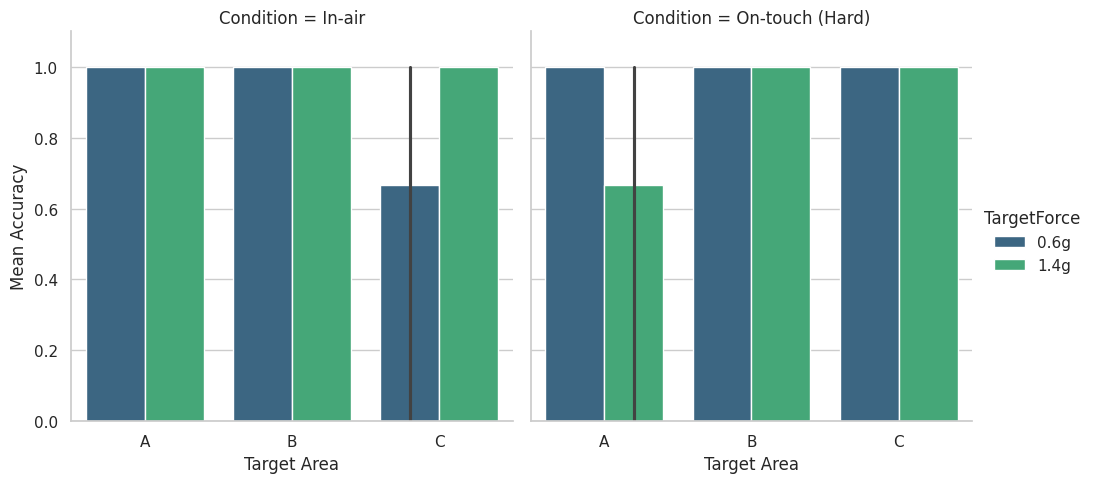

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. 데이터 로드
df_spatial = pd.read_csv('P2_Exp3_SpatialDiscrimination.csv')
df_spatial['IsCorrect'] = df_spatial['IsCorrect'].astype(int)

# 2. 조건 및 강도별 정확도 요약 출력
summary = df_spatial.groupby(['Condition', 'TargetForce'])['IsCorrect'].mean().reset_index()
print("### Spatial Accuracy Summary ###")
print(summary)

# 3. 정확도 시각화 (Area & Force)
sns.set_theme(style="whitegrid")
g = sns.catplot(data=df_spatial, x='TargetArea', y='IsCorrect', hue='TargetForce',
                col='Condition', kind='bar', order=['A', 'B', 'C'], palette='viridis')
g.set_axis_labels("Target Area", "Mean Accuracy")
g.set(ylim=(0, 1.1))
plt.show()

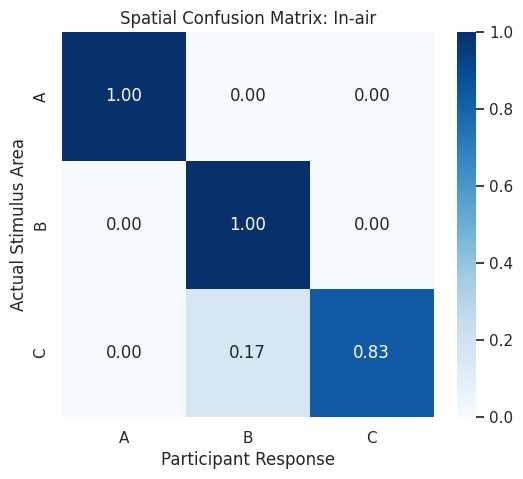

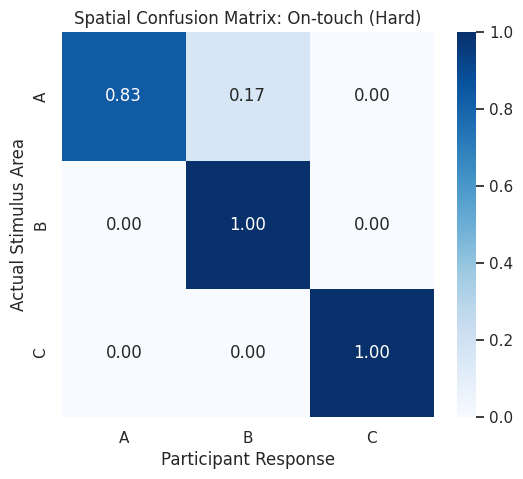

In [8]:
def plot_spatial_confusion(condition_name):
    cond_df = df_spatial[df_spatial['Condition'] == condition_name]
    labels = ['A', 'B', 'C']

    # 혼동 행렬 생성 및 정규화
    cm = confusion_matrix(cond_df['TargetArea'], cond_df['UserChoice'], labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Spatial Confusion Matrix: {condition_name}')
    plt.ylabel('Actual Stimulus Area')
    plt.xlabel('Participant Response')
    plt.show()

# 각 조건별로 히트맵 출력
for cond in df_spatial['Condition'].unique():
    plot_spatial_confusion(cond)

### Localization Error Summary (mm) ###
         Condition TargetForce      mean       std       sem
0           In-air        0.6g  1.111111  3.333333  1.111111
1           In-air        1.4g  0.000000  0.000000  0.000000
2  On-touch (Hard)        0.6g  0.000000  0.000000  0.000000
3  On-touch (Hard)        1.4g  1.111111  3.333333  1.111111


/tmp/ipykernel_5255/646594182.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_spatial, x='Condition', y='LocError_mm', hue='TargetForce',


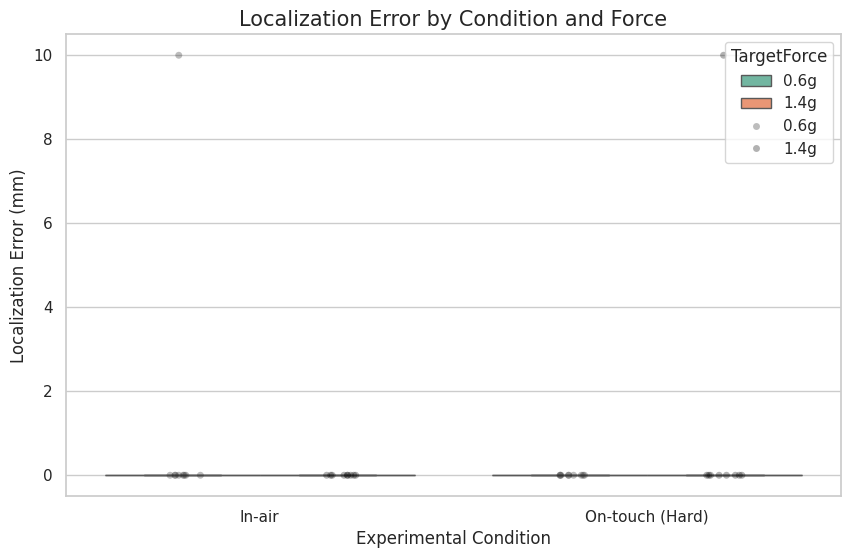

In [9]:
# --- Cell 1: Localization Error (mm) Calculation ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드
df_spatial = pd.read_csv('P2_Exp3_SpatialDiscrimination.csv')

# 2. 구역(Area)을 물리적 좌표(mm)로 매핑
# 예: A=0mm, B=10mm, C=20mm (장치 규격에 맞게 수정 가능)
dist_map = {'A': 0, 'B': 10, 'C': 20}

df_spatial['Target_mm'] = df_spatial['TargetArea'].map(dist_map)
df_spatial['Choice_mm'] = df_spatial['UserChoice'].map(dist_map)

# 3. Localization Error 계산: |실제 위치 - 응답 위치|
df_spatial['LocError_mm'] = np.abs(df_spatial['Target_mm'] - df_spatial['Choice_mm'])

# 4. 조건별 평균 에러 통계 요약
loc_summary = df_spatial.groupby(['Condition', 'TargetForce'])['LocError_mm'].agg(['mean', 'std', 'sem']).reset_index()
print("### Localization Error Summary (mm) ###")
print(loc_summary)

# 5. 시각화 (Boxplot + Stripplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_spatial, x='Condition', y='LocError_mm', hue='TargetForce', palette='Set2', showfliers=False)
sns.stripplot(data=df_spatial, x='Condition', y='LocError_mm', hue='TargetForce',
              dodge=True, color='black', alpha=0.3, jitter=True)

plt.title('Localization Error by Condition and Force', fontsize=15)
plt.ylabel('Localization Error (mm)', fontsize=12)
plt.xlabel('Experimental Condition', fontsize=12)
plt.show()

Estimated TPDT (75% Threshold): 8.67 mm


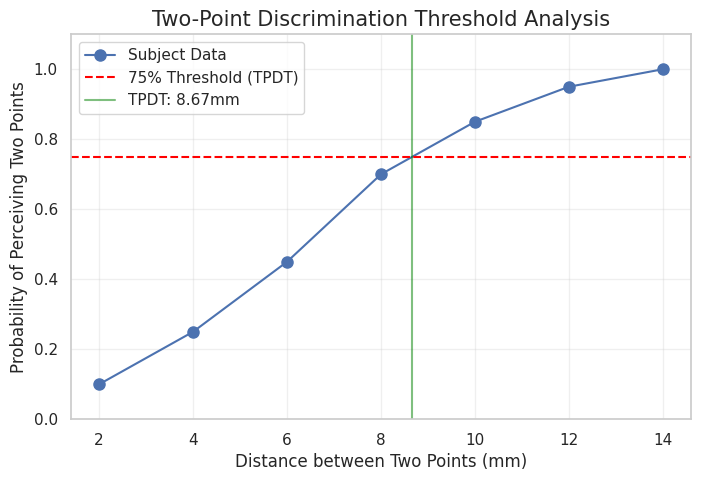

In [10]:
# --- Cell 2: TPDT (Two-Point Discrimination Threshold) Analysis ---
from scipy.interpolate import interp1d

# TPDT 실험 데이터가 아래와 같은 형식이라고 가정합니다 (예시 데이터 생성)
# Distance: 두 점 사이의 거리(mm), Correct_Rate: '두 점'으로 정확히 인지한 비율
tpdt_sample_data = {
    'Distance': [2, 4, 6, 8, 10, 12, 14],
    'Correct_Rate': [0.10, 0.25, 0.45, 0.70, 0.85, 0.95, 1.00]
}
df_tpdt = pd.DataFrame(tpdt_sample_data)

# 1. 시각화 (Psychometric Curve)
plt.figure(figsize=(8, 5))
plt.plot(df_tpdt['Distance'], df_tpdt['Correct_Rate'], 'o-', label='Subject Data', markersize=8)
plt.axhline(0.75, color='red', linestyle='--', label='75% Threshold (TPDT)')

# 2. TPDT 역치 계산 (Linear Interpolation)
# 정답률이 0.75가 되는 Distance 값을 선형 보간으로 찾습니다.
f = interp1d(df_tpdt['Correct_Rate'], df_tpdt['Distance'], kind='linear')
try:
    threshold_75 = f(0.75)
    print(f"Estimated TPDT (75% Threshold): {threshold_75:.2f} mm")
    plt.axvline(threshold_75, color='green', alpha=0.5, label=f'TPDT: {threshold_75:.2f}mm')
except:
    print("Threshold could not be calculated. Accuracy never reached 75%.")

plt.title('Two-Point Discrimination Threshold Analysis', fontsize=15)
plt.xlabel('Distance between Two Points (mm)', fontsize=12)
plt.ylabel('Probability of Perceiving Two Points', fontsize=12)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()